# Multi-Label Emotion Classification

We train and evaluate **three classifiers** on the SemEval-2018 Task 1 (Subtask E-c)
multi-label emotion dataset (11 emotions per tweet).

| # | Experiment | Features | Model |
|---|---|---|---|
| 1 | TF-IDF + Logistic Regression | `text_clean` → TF-IDF | `OneVsRestClassifier(LogisticRegression)` |
| 2 | TF-IDF + Linear SVM | `text_clean` → TF-IDF | `OneVsRestClassifier(LinearSVC)` |
| 3 | Twitter-RoBERTa (pre-trained) | `text_light` | `cardiffnlp/twitter-roberta-base-emotion-multilabel-latest` |

**Data leakage prevention**:
- TF-IDF vocabulary is fit **only** on the train split
- Models are trained **only** on the train split
- Validation split is used for sanity checks / hyperparameter guidance
- **All final metrics are reported on the held-out test split**

**Metrics** (multi-label):
- Macro F1 (primary, SemEval standard)
- Micro F1
- Hamming Loss
- Per-emotion Precision / Recall / F1

## 1. Imports & Configuration

In [1]:
import os
import warnings
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    accuracy_score,
)

# Transformers (for Experiment 3)
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..').resolve()
PROC_DIR  = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'data/models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
            'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

# ── CUDA check ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠ No GPU detected — Experiment 3 (RoBERTa) will run on CPU (slower).')

print('\nImports done')

PyTorch device  : cuda
GPU             : NVIDIA GeForce RTX 3070 Ti
VRAM            : 8.4 GB

Imports done


## 2. Load Data (Train / Validation / Test)

In [2]:
df_train = pd.read_parquet(PROC_DIR / 'train_processed.parquet')
df_val   = pd.read_parquet(PROC_DIR / 'validation_processed.parquet')
df_test  = pd.read_parquet(PROC_DIR / 'test_processed.parquet')

print(f'Train      : {len(df_train):>6,} tweets')
print(f'Validation : {len(df_val):>6,} tweets')
print(f'Test       : {len(df_test):>6,} tweets')
print(f'\nEmotion columns : {EMOTIONS}')

# Targets as numpy arrays
y_train = df_train[EMOTIONS].values
y_val   = df_val[EMOTIONS].values
y_test  = df_test[EMOTIONS].values

print(f'\ny_train shape : {y_train.shape}')
print(f'y_val   shape : {y_val.shape}')
print(f'y_test  shape : {y_test.shape}')

Train      :  6,768 tweets
Validation :    883 tweets
Test       :  3,245 tweets

Emotion columns : ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

y_train shape : (6768, 11)
y_val   shape : (883, 11)
y_test  shape : (3245, 11)


## 3. Feature Extraction — TF-IDF

We fit `TfidfVectorizer` **only on the training set** to prevent data leakage.  
Using word + char n-grams (3–5) to capture sub-word patterns common in tweets.

> ⚠ `text_clean` is used for Experiments 1 & 2 (classical ML).  
> `text_light` will be used for Experiment 3 (RoBERTa).

In [3]:
# Word-level TF-IDF
tfidf_word = TfidfVectorizer(
    analyzer='word',
    max_features=30_000,
    ngram_range=(1, 2),       # uni + bi-grams
    sublinear_tf=True,
    min_df=2,
)

# Char-level TF-IDF  (captures sub-word patterns, typos, slang)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    max_features=30_000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=2,
)

# Fit ONLY on training data  (⬅ no data leakage)
X_train_word = tfidf_word.fit_transform(df_train['text_clean'])
X_train_char = tfidf_char.fit_transform(df_train['text_clean'])

# Transform validation & test
X_val_word  = tfidf_word.transform(df_val['text_clean'])
X_val_char  = tfidf_char.transform(df_val['text_clean'])
X_test_word = tfidf_word.transform(df_test['text_clean'])
X_test_char = tfidf_char.transform(df_test['text_clean'])

# Stack word + char features
from scipy.sparse import hstack

X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word,   X_val_char])
X_test_tfidf  = hstack([X_test_word,  X_test_char])

print(f'TF-IDF feature matrix (train) : {X_train_tfidf.shape}')
print(f'TF-IDF feature matrix (val)   : {X_val_tfidf.shape}')
print(f'TF-IDF feature matrix (test)  : {X_test_tfidf.shape}')

TF-IDF feature matrix (train) : (6768, 44826)
TF-IDF feature matrix (val)   : (883, 44826)
TF-IDF feature matrix (test)  : (3245, 44826)


---

## 4. Experiment 1 — Logistic Regression + TF-IDF

We wrap `LogisticRegression` inside `OneVsRestClassifier` to handle the
11 binary labels independently.

In [4]:
print('═' * 70)
print('  EXPERIMENT 1: Logistic Regression + TF-IDF')
print('═' * 70)

lr_clf = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced',   # handles label imbalance
    ),
    n_jobs=-1,
)

print('Training on train split only...')
lr_clf.fit(X_train_tfidf, y_train)
print('Done.\n')

# ── Predict on test ────────────────────────────────────────────────────────────
y_pred_lr = lr_clf.predict(X_test_tfidf)

# ── Metrics ────────────────────────────────────────────────────────────────────
macro_f1_lr = f1_score(y_test, y_pred_lr, average='macro')
micro_f1_lr = f1_score(y_test, y_pred_lr, average='micro')
h_loss_lr   = hamming_loss(y_test, y_pred_lr)
subset_lr   = accuracy_score(y_test, y_pred_lr)  # exact-match (strict)

print(f'Macro F1      : {macro_f1_lr:.4f}')
print(f'Micro F1      : {micro_f1_lr:.4f}')
print(f'Hamming Loss  : {h_loss_lr:.4f}')
print(f'Subset Acc    : {subset_lr:.4f}  (exact match across all 11 labels)')
print()
print(classification_report(
    y_test, y_pred_lr,
    target_names=EMOTIONS,
    zero_division=0,
    digits=4,
))

══════════════════════════════════════════════════════════════════════
  EXPERIMENT 1: Logistic Regression + TF-IDF
══════════════════════════════════════════════════════════════════════
Training on train split only...
Done.

Macro F1      : 0.5222
Micro F1      : 0.6273
Hamming Loss  : 0.1702
Subset Acc    : 0.1602  (exact match across all 11 labels)

              precision    recall  f1-score   support

       anger     0.7004    0.7183    0.7093      1097
anticipation     0.2491    0.3168    0.2789       423
     disgust     0.6447    0.6776    0.6607      1095
        fear     0.6809    0.6936    0.6872       483
         joy     0.8190    0.8047    0.8118      1439
        love     0.5503    0.6583    0.5995       515
    optimism     0.6325    0.6608    0.6463      1138
   pessimism     0.3156    0.4301    0.3641       372
     sadness     0.6251    0.6761    0.6496       957
    surprise     0.2047    0.2059    0.2053       170
       trust     0.1101    0.1634    0.1316       

---

## 5. Experiment 2 — Linear SVM + TF-IDF

Same feature set, but using `LinearSVC` (hinge loss) instead of logistic loss.

In [5]:
print('═' * 70)
print('  EXPERIMENT 2: Linear SVM + TF-IDF')
print('═' * 70)

svm_clf = OneVsRestClassifier(
    LinearSVC(
        C=1.0,
        max_iter=2000,
        class_weight='balanced',
    ),
    n_jobs=-1,
)

print('Training on train split only...')
svm_clf.fit(X_train_tfidf, y_train)
print('Done.\n')

# ── Predict on test ────────────────────────────────────────────────────────────
y_pred_svm = svm_clf.predict(X_test_tfidf)

# ── Metrics ────────────────────────────────────────────────────────────────────
macro_f1_svm = f1_score(y_test, y_pred_svm, average='macro')
micro_f1_svm = f1_score(y_test, y_pred_svm, average='micro')
h_loss_svm   = hamming_loss(y_test, y_pred_svm)
subset_svm   = accuracy_score(y_test, y_pred_svm)

print(f'Macro F1      : {macro_f1_svm:.4f}')
print(f'Micro F1      : {micro_f1_svm:.4f}')
print(f'Hamming Loss  : {h_loss_svm:.4f}')
print(f'Subset Acc    : {subset_svm:.4f}')
print()
print(classification_report(
    y_test, y_pred_svm,
    target_names=EMOTIONS,
    zero_division=0,
    digits=4,
))

══════════════════════════════════════════════════════════════════════
  EXPERIMENT 2: Linear SVM + TF-IDF
══════════════════════════════════════════════════════════════════════
Training on train split only...
Done.

Macro F1      : 0.4891
Micro F1      : 0.6068
Hamming Loss  : 0.1715
Subset Acc    : 0.1569

              precision    recall  f1-score   support

       anger     0.6958    0.6901    0.6929      1097
anticipation     0.2243    0.2222    0.2233       423
     disgust     0.6143    0.6256    0.6199      1095
        fear     0.6533    0.6749    0.6640       483
         joy     0.8123    0.7908    0.8014      1439
        love     0.5835    0.5359    0.5587       515
    optimism     0.6245    0.6037    0.6139      1138
   pessimism     0.3052    0.3306    0.3174       372
     sadness     0.5988    0.6270    0.6126       957
    surprise     0.2037    0.1294    0.1583       170
       trust     0.1345    0.1046    0.1176       153

   micro avg     0.6114    0.6024    0.6

---

## 6. Experiment 3 — Twitter-RoBERTa (Pre-trained, Multi-label)

We use **`cardiffnlp/twitter-roberta-base-emotion-multilabel-latest`** —
a RoBERTa model fine-tuned on the TweetEval emotion benchmark.

Since the model is already trained for multi-label emotion classification,
we perform **zero-shot inference** (no further fine-tuning → no overfitting risk).

**Emotion label mapping**: The model's label set may differ from our 11 emotions.
We map only the labels that overlap and evaluate accordingly.


In [6]:
print('═' * 70)
print('  EXPERIMENT 3: Twitter-RoBERTa (pre-trained emotion multi-label)')
print('═' * 70)

ROBERTA_MODEL = 'cardiffnlp/twitter-roberta-base-emotion-multilabel-latest'

print(f'\nLoading model: {ROBERTA_MODEL}')
print(f'Device       : {DEVICE}\n')

tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL)
model     = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL)
model     = model.to(DEVICE)
model.eval()

# ── Inspect the model's label set ──────────────────────────────────────────────
id2label = model.config.id2label
roberta_labels = [id2label[i] for i in range(len(id2label))]
print(f'RoBERTa label set ({len(roberta_labels)}): {roberta_labels}')
print(f'Our label set     ({len(EMOTIONS)}): {EMOTIONS}\n')

# Build mapping: our emotion index → roberta class index (if it exists)
label_map = {}   # {our_idx: roberta_idx}
for our_idx, emo in enumerate(EMOTIONS):
    for rob_idx, rob_label in enumerate(roberta_labels):
        if rob_label.lower() == emo.lower():
            label_map[our_idx] = rob_idx
            break

mapped_emotions = [EMOTIONS[i] for i in sorted(label_map.keys())]
print(f'Mapped emotions ({len(mapped_emotions)}): {mapped_emotions}')
unmapped = [e for e in EMOTIONS if e not in mapped_emotions]
if unmapped:
    print(f'Unmapped (skipped in RoBERTa eval): {unmapped}')

══════════════════════════════════════════════════════════════════════
  EXPERIMENT 3: Twitter-RoBERTa (pre-trained emotion multi-label)
══════════════════════════════════════════════════════════════════════

Loading model: cardiffnlp/twitter-roberta-base-emotion-multilabel-latest
Device       : cuda

RoBERTa label set (11): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
Our label set     (11): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

Mapped emotions (11): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']


In [7]:
# ── Inference on test set ──────────────────────────────────────────────────────
BATCH_SIZE = 32
THRESHOLD  = 0.5

test_texts = df_test['text_light'].tolist()

all_probs = []   # list of np arrays, shape (batch, num_roberta_labels)

print(f'Running inference on {len(test_texts)} test samples (batch={BATCH_SIZE})...')
for start in range(0, len(test_texts), BATCH_SIZE):
    batch = test_texts[start : start + BATCH_SIZE]
    enc = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt',
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.sigmoid(logits).cpu().numpy()
    all_probs.append(probs)

    if (start // BATCH_SIZE) % 20 == 0:
        print(f'  processed {min(start + BATCH_SIZE, len(test_texts)):>5}/{len(test_texts)}')

all_probs = np.vstack(all_probs)                     # (N_test, num_roberta_labels)
print(f'\nProbabilities shape: {all_probs.shape}')

# ── Build y_pred aligned with OUR 11-emotion order ─────────────────────────────
y_pred_roberta = np.zeros_like(y_test, dtype=int)     # (N_test, 11)

for our_idx, rob_idx in label_map.items():
    y_pred_roberta[:, our_idx] = (all_probs[:, rob_idx] >= THRESHOLD).astype(int)

# For unmapped emotions, leave predictions as 0  (conservative: predict absent)
print('Predictions ready.')

Running inference on 3245 test samples (batch=32)...
  processed    32/3245
  processed   672/3245
  processed  1312/3245
  processed  1952/3245
  processed  2592/3245
  processed  3232/3245

Probabilities shape: (3245, 11)
Predictions ready.


In [8]:
# ── Metrics — full 11-label evaluation ─────────────────────────────────────────
macro_f1_rob = f1_score(y_test, y_pred_roberta, average='macro')
micro_f1_rob = f1_score(y_test, y_pred_roberta, average='micro')
h_loss_rob   = hamming_loss(y_test, y_pred_roberta)
subset_rob   = accuracy_score(y_test, y_pred_roberta)

print(f'=== Full 11-label evaluation (unmapped emotions treated as 0) ===')
print(f'Macro F1      : {macro_f1_rob:.4f}')
print(f'Micro F1      : {micro_f1_rob:.4f}')
print(f'Hamming Loss  : {h_loss_rob:.4f}')
print(f'Subset Acc    : {subset_rob:.4f}')
print()
print(classification_report(
    y_test, y_pred_roberta,
    target_names=EMOTIONS,
    zero_division=0,
    digits=4,
))

# ── Metrics — only mapped labels ───────────────────────────────────────────────
if len(mapped_emotions) < len(EMOTIONS):
    mapped_idxs = sorted(label_map.keys())
    y_test_mapped = y_test[:, mapped_idxs]
    y_pred_mapped = y_pred_roberta[:, mapped_idxs]

    macro_f1_rob_m = f1_score(y_test_mapped, y_pred_mapped, average='macro')
    micro_f1_rob_m = f1_score(y_test_mapped, y_pred_mapped, average='micro')

    print(f'\n=== Mapped-only evaluation ({len(mapped_emotions)} emotions) ===')
    print(f'Macro F1 (mapped) : {macro_f1_rob_m:.4f}')
    print(f'Micro F1 (mapped) : {micro_f1_rob_m:.4f}')
    print()
    print(classification_report(
        y_test_mapped, y_pred_mapped,
        target_names=mapped_emotions,
        zero_division=0,
        digits=4,
    ))

=== Full 11-label evaluation (unmapped emotions treated as 0) ===
Macro F1      : 0.5443
Micro F1      : 0.7134
Hamming Loss  : 0.1185
Subset Acc    : 0.2912

              precision    recall  f1-score   support

       anger     0.7886    0.8058    0.7971      1097
anticipation     0.4645    0.1702    0.2491       423
     disgust     0.7291    0.7717    0.7498      1095
        fear     0.7719    0.7288    0.7497       483
         joy     0.8712    0.8464    0.8587      1439
        love     0.7169    0.5262    0.6069       515
    optimism     0.7418    0.7373    0.7395      1138
   pessimism     0.4868    0.2473    0.3280       372
     sadness     0.7536    0.7032    0.7276       957
    surprise     0.5152    0.1000    0.1675       170
       trust     0.3333    0.0065    0.0128       153

   micro avg     0.7611    0.6713    0.7134      7842
   macro avg     0.6521    0.5130    0.5443      7842
weighted avg     0.7321    0.6713    0.6888      7842
 samples avg     0.7513    0.

---

## 7. Comparison — All Three Experiments

In [9]:
# ── Summary table ──────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Experiment': [
        '1. LR + TF-IDF',
        '2. SVM + TF-IDF',
        '3. RoBERTa (pre-trained)',
    ],
    'Macro F1': [macro_f1_lr, macro_f1_svm, macro_f1_rob],
    'Micro F1': [micro_f1_lr, micro_f1_svm, micro_f1_rob],
    'Hamming Loss': [h_loss_lr, h_loss_svm, h_loss_rob],
    'Subset Accuracy': [subset_lr, subset_svm, subset_rob],
})

styled = (
    summary.style
    .set_caption('📊 Multi-Label Emotion Classification — Test Set Results')
    .format({
        'Macro F1': '{:.4f}',
        'Micro F1': '{:.4f}',
        'Hamming Loss': '{:.4f}',
        'Subset Accuracy': '{:.4f}',
    })
    .background_gradient(subset=['Macro F1'], cmap='Greens')
    .background_gradient(subset=['Micro F1'], cmap='Blues')
    .background_gradient(subset=['Hamming Loss'], cmap='Reds_r')   # lower is better
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding', '8px 0')]},
        {'selector': 'th', 'props': [('background-color', 'dark-grey'),
                                      ('padding', '8px 12px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
    .hide(axis='index')
)

display(styled)

Experiment,Macro F1,Micro F1,Hamming Loss,Subset Accuracy
1. LR + TF-IDF,0.5222,0.6273,0.1702,0.1602
2. SVM + TF-IDF,0.4891,0.6068,0.1715,0.1569
3. RoBERTa (pre-trained),0.5443,0.7134,0.1185,0.2912


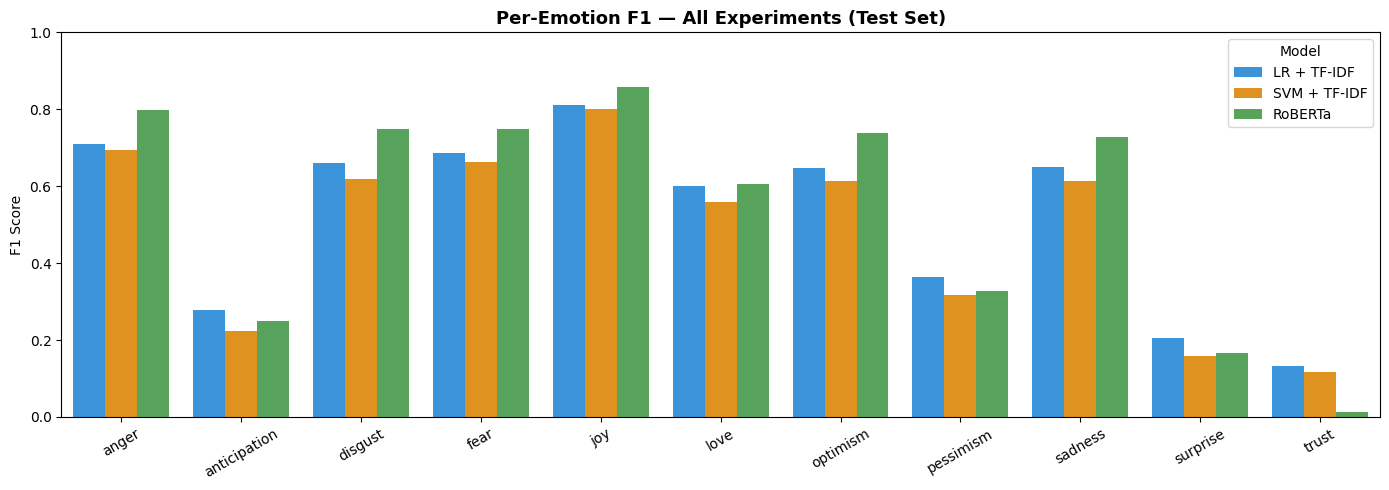

Chart saved.


In [10]:
# ── Per-emotion F1 comparison chart ────────────────────────────────────────────
per_emo_f1_lr  = f1_score(y_test, y_pred_lr,      average=None)
per_emo_f1_svm = f1_score(y_test, y_pred_svm,     average=None)
per_emo_f1_rob = f1_score(y_test, y_pred_roberta,  average=None)

f1_df = pd.DataFrame({
    'Emotion': EMOTIONS * 3,
    'F1': np.concatenate([per_emo_f1_lr, per_emo_f1_svm, per_emo_f1_rob]),
    'Model': (['LR + TF-IDF'] * 11) + (['SVM + TF-IDF'] * 11) + (['RoBERTa'] * 11),
})

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=f1_df, x='Emotion', y='F1', hue='Model',
            palette=['#2196F3', '#FF9800', '#4CAF50'], ax=ax)
ax.set_title('Per-Emotion F1 — All Experiments (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Model', loc='upper right')
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(MODEL_DIR / 'per_emotion_f1_comparison.png', dpi=120)
plt.show()
print('Chart saved.')

## 8. Save Results

In [11]:
import pickle

# ── Save Logistic Regression model ───────────────────────────────────────
with open(MODEL_DIR / 'lr_clf.pkl', 'wb') as f:
    pickle.dump(lr_clf, f)

# ── Save SVM model ────────────────────────────────────────────────────────
with open(MODEL_DIR / 'svm_clf.pkl', 'wb') as f:
    pickle.dump(svm_clf, f)

# ── Save TF-IDF vectorizers ───────────────────────────────────────────────
with open(MODEL_DIR / 'tfidf_word.pkl', 'wb') as f:
    pickle.dump(tfidf_word, f)
with open(MODEL_DIR / 'tfidf_char.pkl', 'wb') as f:
    pickle.dump(tfidf_char, f)

print('Models saved:')
print(f'  LR Classifier  → {MODEL_DIR}/lr_clf.pkl')
print(f'  SVM Classifier → {MODEL_DIR}/svm_clf.pkl')
print(f'  TF-IDF word    → {MODEL_DIR}/tfidf_word.pkl')
print(f'  TF-IDF char    → {MODEL_DIR}/tfidf_char.pkl')

# ── List artefacts ────────────────────────────────────────────────────────
print(f'\nArtefacts in {MODEL_DIR}:')
for p in sorted(MODEL_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:45s} {size_kb:>8.1f} KB')


Models saved:
  LR Classifier  → /home/nasty/Desktop/hua/SocialMediaAgent/data/models/lr_clf.pkl
  SVM Classifier → /home/nasty/Desktop/hua/SocialMediaAgent/data/models/svm_clf.pkl
  TF-IDF word    → /home/nasty/Desktop/hua/SocialMediaAgent/data/models/tfidf_word.pkl
  TF-IDF char    → /home/nasty/Desktop/hua/SocialMediaAgent/data/models/tfidf_char.pkl

Artefacts in /home/nasty/Desktop/hua/SocialMediaAgent/data/models:
  lr_clf.pkl                                      3857.7 KB
  lr_pipeline.pkl                                  552.0 KB
  per_emotion_f1_comparison.png                     48.4 KB
  svm_clf.pkl                                     3856.9 KB
  svm_pipeline.pkl                                 551.1 KB
  tfidf_char.pkl                                  1005.8 KB
  tfidf_word.pkl                                   582.8 KB
